<a href="https://colab.research.google.com/github/eisejuaz/UGR-Introduccion-a-ciencia-de-datos-2026/blob/main/Introducci%C3%B3n_a_Ciencia_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Materia:
Introduccióna Ciencia de Datos

## Carrera
Tecnicatura universitaria en Ciencia de Datos e IA

## Año
2026

## Integrantes
Deheza, Julian
Gargiulo, Franco
Girondo, Mauro
Tusoli, Melisa

# SETUP INICIAL

### Import de librerías y secrets

In [ ]:
from google.colab import userdata, drive
import pathlib
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gdown


### Paths para el dataset desde una URL pública de Google Drive

In [ ]:
# Se extrae el dataset desde google drive
# El ID del archivo de Google Drive de tu URL
file_id = '1ftNIrya9c9B_smlUSsRlyfqciRmov3ha'
output_filename = 'downloaded_data.csv'

# Descarga el archivo usando gdown
gdown.download(id=file_id, output=output_filename, quiet=False)

# Ahora, lee el archivo CSV descargado con pandas
df = pd.read_csv(output_filename)

# Muestra las primeras 5 filas del DataFrame
display(df.head())

Downloading...
From: https://drive.google.com/uc?id=1ftNIrya9c9B_smlUSsRlyfqciRmov3ha
To: /content/downloaded_data.csv
100%|██████████| 2.05M/2.05M [00:00<00:00, 48.3MB/s]


,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
0,4002,925,Gold,social_media,2024-07-22,124,American,Los Angeles,3.6,23,...,25.42,PROMO-BFUZ,percentage,4.97,completed,2.9,25.6,True,True,NaN
1,4879,3163,Bronze,referral,2023-03-17,43,Chinese,Houston,4.8,32,...,22.70,NaN,NaN,0.00,completed,4.0,0.4,True,True,NaN
2,1124,4154,Bronze,referral,2023-01-14,188,American,San Antonio,3.4,11,...,27.74,NaN,NaN,0.00,completed,4.4,0.0,True,True,NaN
3,6764,4530,Bronze,email,2024-02-26,91,Mediterranean,New York,3.1,17,...,31.85,NaN,NaN,0.00,completed,9.9,0.0,True,True,NaN
4,9073,2570,Bronze,paid_ads,2024-08-25,84,Mediterranean,San Antonio,3.2,28,...,28.46,NaN,NaN,0.00,completed,7.0,16.1,True,True,NaN


# PRIMERAS EXPLORACIONES DEL DATASET

## Lectura y sample


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   order_id                      10000 non-null  int64  
 1   customer_id                   10000 non-null  int64  
 2   customer_loyalty_tier         10000 non-null  object 
 3   customer_acquisition_channel  10000 non-null  object 
 4   customer_signup_date          10000 non-null  object 
 5   restaurant_id                 10000 non-null  int64  
 6   restaurant_cuisine            10000 non-null  object 
 7   restaurant_city               10000 non-null  object 
 8   restaurant_rating             10000 non-null  float64
 9   restaurant_avg_prep_time      10000 non-null  int64  
 10  menu_item_id                  10000 non-null  int64  
 11  menu_item_name                10000 non-null  object 
 12  menu_item_category            10000 non-null  object 
 13  it

### Info acerca de columnas numéricas

In [ ]:
df.describe()

,order_id,customer_id,restaurant_id,restaurant_rating,restaurant_avg_prep_time,menu_item_id,item_price,quantity,delivery_duration_actual,delivery_duration_estimated,delivery_fee,tip,total_amount,discount_value,weather_temperature,weather_precipitation
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9225.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,6000.50000,5008.065000,101.806200,4.010830,22.278600,548.848900,20.135489,1.380700,48.252033,41.802300,5.019878,3.458260,35.285542,0.96246,14.943640,0.980470
std,2886.89568,2889.998361,57.795156,0.585262,7.093576,319.936271,8.509875,0.743386,11.630734,9.203439,1.732529,3.533187,22.571144,2.33411,7.681618,2.912181
min,1001.00000,1.000000,1.000000,3.000000,10.000000,1.000000,5.030000,1.000000,16.000000,20.000000,1.990000,0.000000,2.480000,0.00000,-5.200000,0.000000
25%,3500.75000,2490.000000,52.000000,3.500000,16.000000,270.000000,12.590000,1.000000,40.000000,35.000000,3.530000,1.127500,20.807500,0.00000,8.400000,0.000000
50%,6000.50000,4982.500000,101.000000,4.100000,22.000000,546.000000,20.460000,1.000000,48.000000,42.000000,5.020000,2.490000,30.525000,0.00000,14.800000,0.000000
75%,8500.25000,7544.250000,152.000000,4.500000,28.000000,824.000000,27.520000,2.000000,56.000000,48.250000,6.540000,4.580000,40.330000,0.00000,21.500000,0.000000
max,11000.00000,9999.000000,200.000000,5.000000,34.000000,1109.000000,34.940000,4.000000,89.000000,63.000000,7.990000,33.220000,176.500000,26.81000,33.800000,36.000000


### Revisión general, para ver algunos valores categóricos que puedan repetirse por sobre otros

In [ ]:
df.describe(include="all")

,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
count,10000.00000,10000.000000,10000,10000,10000,10000.000000,10000,10000,10000.000000,10000.000000,...,10000.000000,1950,1950,10000.00000,10000,10000.000000,10000.000000,10000,10000,790
unique,NaN,NaN,3,5,730,NaN,8,8,NaN,NaN,...,NaN,1949,3,NaN,2,NaN,NaN,2,2,1
top,NaN,NaN,Bronze,paid_ads,2024-04-26,NaN,American,New York,NaN,NaN,...,NaN,PROMO-WOKZ,percentage,NaN,completed,NaN,NaN,False,False,Valentines
freq,NaN,NaN,6042,2028,33,NaN,1836,1705,NaN,NaN,...,NaN,2,682,NaN,9225,NaN,NaN,7102,9708,790
mean,6000.50000,5008.065000,NaN,NaN,NaN,101.806200,NaN,NaN,4.010830,22.278600,...,35.285542,NaN,NaN,0.96246,NaN,14.943640,0.980470,NaN,NaN,NaN
std,2886.89568,2889.998361,NaN,NaN,NaN,57.795156,NaN,NaN,0.585262,7.093576,...,22.571144,NaN,NaN,2.33411,NaN,7.681618,2.912181,NaN,NaN,NaN
min,1001.00000,1.000000,NaN,NaN,NaN,1.000000,NaN,NaN,3.000000,10.000000,...,2.480000,NaN,NaN,0.00000,NaN,-5.200000,0.000000,NaN,NaN,NaN
25%,3500.75000,2490.000000,NaN,NaN,NaN,52.000000,NaN,NaN,3.500000,16.000000,...,20.807500,NaN,NaN,0.00000,NaN,8.400000,0.000000,NaN,NaN,NaN
50%,6000.50000,4982.500000,NaN,NaN,NaN,101.000000,NaN,NaN,4.100000,22.000000,...,30.525000,NaN,NaN,0.00000,NaN,14.800000,0.000000,NaN,NaN,NaN
75%,8500.25000,7544.250000,NaN,NaN,NaN,152.000000,NaN,NaN,4.500000,28.000000,...,40.330000,NaN,NaN,0.00000,NaN,21.500000,0.000000,NaN,NaN,NaN


### Data types


In [ ]:
df.dtypes

,0
order_id,int64
customer_id,int64
customer_loyalty_tier,object
customer_acquisition_channel,object
customer_signup_date,object
restaurant_id,int64
restaurant_cuisine,object
restaurant_city,object
restaurant_rating,float64
restaurant_avg_prep_time,int64


### Valores únicos

Valores únicos en cada columna y un ratios. Exploramos ids, categorical data, etc, usando la estrategia de considerar ratio 100, entonces equivale a ids únicos, y ratios bajos indican con bastante seguridad data categórica o boolean.

In [ ]:
summary = df.nunique().reset_index()
summary.columns = ["columna", "unicos"]
summary["ratio"] = (summary["unicos"] / len(df) * 100).round(2)

summary

,columna,unicos,ratio
0,order_id,10000,100.00
1,customer_id,6259,62.59
2,customer_loyalty_tier,3,0.03
3,customer_acquisition_channel,5,0.05
4,customer_signup_date,730,7.30
5,restaurant_id,200,2.00
6,restaurant_cuisine,8,0.08
7,restaurant_city,8,0.08
8,restaurant_rating,21,0.21
9,restaurant_avg_prep_time,25,0.25


Probamos la función para ver valores únicos simplificada.

In [ ]:
df.nunique()

,0
order_id,10000
customer_id,6259
customer_loyalty_tier,3
customer_acquisition_channel,5
customer_signup_date,730
restaurant_id,200
restaurant_cuisine,8
restaurant_city,8
restaurant_rating,21
restaurant_avg_prep_time,25


### Duplicados

Buscamos duplicados, y, si hubiera, vemos ejemplos.

In [ ]:
dup_rows = df.duplicated().sum()
print(f"Filas duplicadas: {dup_rows}")

df[df.duplicated()].head()

Filas duplicadas: 0


,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag


Zoom de duplicados a nuestra fila principal, order_id:

In [ ]:
dup_orders = df["order_id"].duplicated().sum()
print(f"Órdenes duplicadas: {dup_orders}")


Órdenes duplicadas: 0


Generamos un duplicado para validar que nuestro método de detección funcione

In [ ]:
row_to_dup = df.loc[[5]]  # fila con índice 5
df = pd.concat([df, row_to_dup], ignore_index=True)

dup_rows = df.duplicated().sum()
print(f"Filas duplicadas: {dup_rows}")

Filas duplicadas: 1


Encontramos 1 duplicado, como era de esperarse, entonces imprimimos.

In [ ]:
df[df.duplicated(keep=False)]


,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
5,7005,2816,Bronze,email,2023-05-28,161,American,Houston,3.8,15,...,64.0,NaN,NaN,0.0,completed,2.3,1.5,True,True,NaN
10000,7005,2816,Bronze,email,2023-05-28,161,American,Houston,3.8,15,...,64.0,NaN,NaN,0.0,completed,2.3,1.5,True,True,NaN


Luego lo eliminamos para volver a la situación inicial, conservando la primera ocurrencia.
Finalmente validamos, y revisamos la fila índice 5 para confirmar nuestra acción.

In [ ]:
df = df.drop_duplicates(keep="first")

dup_rows = df.duplicated().sum()
print(f"Filas duplicadas: {dup_rows}")

df.loc[[5]]

Filas duplicadas: 0


,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
5,7005,2816,Bronze,email,2023-05-28,161,American,Houston,3.8,15,...,64.0,NaN,NaN,0.0,completed,2.3,1.5,True,True,NaN


### Nulls

Revisamos nulls en todo el dataset.

In [ ]:
nulls = df.isna().sum()
nulls_pct = (df.isna().mean() * 100).round(2)

nulls_df = pd.DataFrame({
    "nulls": nulls,
    "pct": nulls_pct
}).sort_values("pct", ascending=False)

print(nulls_df)

                              nulls    pct
event_flag                     9210  92.10
discount_code                  8050  80.50
discount_type                  8050  80.50
delivery_timestamp              775   7.75
delivery_duration_actual        775   7.75
customer_id                       0   0.00
order_id                          0   0.00
restaurant_city                   0   0.00
restaurant_rating                 0   0.00
restaurant_avg_prep_time          0   0.00
customer_loyalty_tier             0   0.00
customer_acquisition_channel      0   0.00
customer_signup_date              0   0.00
restaurant_id                     0   0.00
restaurant_cuisine                0   0.00
quantity                          0   0.00
item_price                        0   0.00
menu_item_category                0   0.00
menu_item_name                    0   0.00
menu_item_id                      0   0.00
delivery_fee                      0   0.00
delivery_duration_estimated       0   0.00
order_times

Al encontrar nulls, hacemos zoom específicamente en ellos.

In [ ]:
print(nulls_df[nulls_df["nulls"] > 0])

                          nulls    pct
event_flag                 9210  92.10
discount_code              8050  80.50
discount_type              8050  80.50
delivery_timestamp          775   7.75
delivery_duration_actual    775   7.75


In [ ]:
df.index += 1
df

,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
1,4002,925,Gold,social_media,2024-07-22,124,American,Los Angeles,3.6,23,...,25.42,PROMO-BFUZ,percentage,4.97,completed,2.9,25.6,True,True,NaN
2,4879,3163,Bronze,referral,2023-03-17,43,Chinese,Houston,4.8,32,...,22.70,NaN,NaN,0.00,completed,4.0,0.4,True,True,NaN
3,1124,4154,Bronze,referral,2023-01-14,188,American,San Antonio,3.4,11,...,27.74,NaN,NaN,0.00,completed,4.4,0.0,True,True,NaN
4,6764,4530,Bronze,email,2024-02-26,91,Mediterranean,New York,3.1,17,...,31.85,NaN,NaN,0.00,completed,9.9,0.0,True,True,NaN
5,9073,2570,Bronze,paid_ads,2024-08-25,84,Mediterranean,San Antonio,3.2,28,...,28.46,NaN,NaN,0.00,completed,7.0,16.1,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,6028,7849,Bronze,referral,2024-06-26,122,Mexican,Phoenix,4.4,18,...,43.34,NaN,NaN,0.00,completed,4.7,0.0,False,False,NaN
9997,6760,330,Silver,social_media,2023-07-28,103,Chinese,Chicago,4.1,30,...,135.07,NaN,NaN,0.00,cancelled,7.4,0.0,False,False,NaN
9998,3727,5447,Silver,organic,2023-06-11,173,Fast Food,Los Angeles,3.2,32,...,11.63,NaN,NaN,0.00,completed,7.5,0.0,False,False,NaN
9999,9730,8202,Bronze,social_media,2023-12-17,141,Mediterranean,Chicago,4.0,33,...,29.69,NaN,NaN,0.00,completed,3.4,0.0,False,False,NaN


### Variables relevantes detectadas en la exploración inicial

Luego de revisar la estructura del dataset, los valores nulos, los valores únicos y algunas métricas generales, identificamos variables que pueden aportar al análisis de la experiencia del cliente.

En esta sección calculamos algunos indicadores iniciales para observar si existen diferencias relevantes en cancelaciones, ciudades y tipos de clientes.

Indicadores generales de pedidos y cancelaciones:

In [ ]:
total_pedidos = len(df)
cancelados = (df["order_status"] == "cancelled").sum()
tasa_cancelacion = cancelados / total_pedidos * 100

print(f"Total de pedidos: {total_pedidos}")
print(f"Pedidos cancelados: {cancelados}")
print(f"Tasa de cancelación: {tasa_cancelacion:.2f}%")

Total de pedidos: 10000
Pedidos cancelados: 775
Tasa de cancelación: 7.75%


Cancelaciones por ciudad

In [ ]:
cancelacion_ciudad = (
    df.groupby("restaurant_city")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=False)
)

cancelacion_ciudad

,pedidos,cancelados,tasa_cancelacion
restaurant_city,,,
Phoenix,752,72,9.574468
Chicago,1474,135,9.158752
Philadelphia,1064,84,7.894737
San Antonio,1155,91,7.878788
Houston,1448,111,7.665746
New York,1705,125,7.331378
Los Angeles,943,65,6.892895
San Diego,1459,92,6.305689


Cancelaciones y monto promedio por tipo de cliente

In [ ]:
cancelacion_cliente = (
    df.groupby("customer_loyalty_tier")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum()),
        monto_promedio=("total_amount", "mean")
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=False)
)

cancelacion_cliente["monto_promedio"] = cancelacion_cliente["monto_promedio"].round(2)
cancelacion_cliente["tasa_cancelacion"] = cancelacion_cliente["tasa_cancelacion"].round(2).astype(str) + "%"

cancelacion_cliente

,pedidos,cancelados,monto_promedio,tasa_cancelacion
customer_loyalty_tier,,,,
Bronze,6042,480,34.74,7.94%
Gold,917,72,35.45,7.85%
Silver,3041,223,36.33,7.33%


# OBJETIVO DEL PROYECTO

Disminución y prevención de cancelaciones en pedidos de delivery mediante el análisis de factores comerciales, operativos, climáticos y de comportamiento del cliente.

1.  Analizar el comportamiento de compra de los clientes
2.  Evaluar el desempeño operativo de las entregas
3.  Analizar el impacto en cancelaciones y promociones
4.  Evaluar la relación entre las ciudades y tiempos de entrega según los diversos factores.
5.  Proponer estrategias de optimización del servicio de delivery orientadas a reducir cancelaciones, mejorar la experiencia del cliente y aumentar la eficiencia operativa.








# EDA ORIENTADO A LOS OBJETIVOS DEL PROYECTO

A partir de la exploración inicial del dataset, seleccionamos las variables más relevantes para analizar la experiencia del cliente en el servicio de delivery:

- `order_status`: será la guía que oriente nuestra investigación.
- `restaurant_city`: porque permite evaluar diferencias por ciudad.
- `delivery_duration_actual` y `delivery_duration_estimated`: permiten medir demora en la entrega(tiempo estimado vs real).
- `customer_loyalty_tier`: porque permite comparar el comportamiento según tipo de cliente(Gold,Bronze,Silver).
- `discount_type`: porque permite analizar el efecto de descuentos y promociones.
- `total_amount`: porque permite analizar el valor de compra.
- `is_weekend` e `is_holiday`: permiten comparar los dias de la semana vs los fines de semana.
- `weather_precipitation`: porque permite analizar si el clima influye en la experiencia.

## Visualizaciones

### Pedidos completados vs cancelados

Comienzo de la analítica. Nuestro eje será ver qué categorías se desvían del porcentaje de cancelaciones general, para buscar acciones específicas que busquen minimizar su impacto.

In [ ]:
# ============================================================
# RESUMEN EDA PARA VALIDAR HALLAZGOS PRINCIPALES
# ============================================================

import pandas as pd

try:
    df_val = df.copy()
except NameError:
    df_val = pd.read_csv("downloaded_data.csv")

# Variables auxiliares
df_val["is_cancelled"] = (df_val["order_status"] == "cancelled").astype(int)

df_val["delay_minutes"] = (
    df_val["delivery_duration_actual"] - df_val["delivery_duration_estimated"]
)

df_val["tiene_descuento"] = df_val["discount_type"].notna()

# ============================================================
# 1. Base general
# ============================================================

total_pedidos = len(df_val)
cancelados = df_val["is_cancelled"].sum()
completados = total_pedidos - cancelados
tasa_general = cancelados / total_pedidos * 100

print("=== BASE GENERAL ===")
print(f"Total pedidos: {total_pedidos}")
print(f"Completados: {completados}")
print(f"Cancelados: {cancelados}")
print(f"Tasa general de cancelación: {tasa_general:.2f}%")

# ============================================================
# Función general para variables categóricas
# ============================================================

def resumen_categoria(columna, nombre):
    resumen = (
        df_val.groupby(columna, observed=False)
        .agg(
            pedidos=("order_id", "count"),
            cancelados=("is_cancelled", "sum")
        )
    )

    resumen["pct_pedidos"] = (
        resumen["pedidos"] / total_pedidos * 100
    ).round(2)

    resumen["tasa_cancelacion"] = (
        resumen["cancelados"] / resumen["pedidos"] * 100
    ).round(2)

    resumen["dif_vs_tasa_general"] = (
        resumen["tasa_cancelacion"] - tasa_general
    ).round(2)

    resumen = resumen.sort_values("tasa_cancelacion", ascending=False)

    print(f"\n=== {nombre.upper()} ===")
    print(resumen)

    return resumen

# ============================================================
# 2. Variables principales del EDA
# ============================================================

resumen_ciudad = resumen_categoria(
    "restaurant_city",
    "Cancelación por ciudad"
)

resumen_cliente = resumen_categoria(
    "customer_loyalty_tier",
    "Cancelación por tipo de cliente"
)

resumen_plato = resumen_categoria(
    "menu_item_category",
    "Cancelación por categoría de plato"
)

resumen_canal = resumen_categoria(
    "customer_acquisition_channel",
    "Cancelación por canal de adquisición"
)

resumen_descuento = resumen_categoria(
    "tiene_descuento",
    "Cancelación con y sin descuento"
)

# ============================================================
# 3. Lluvia / precipitación
# ============================================================

df_val["categoria_lluvia"] = pd.cut(
    df_val["weather_precipitation"],
    bins=[-0.1, 0.1, 5, 20, df_val["weather_precipitation"].max() + 0.1],
    labels=["Sin lluvia", "Lluvia ligera", "Lluvia moderada", "Lluvia intensa"]
)

resumen_lluvia = resumen_categoria(
    "categoria_lluvia",
    "Cancelación por lluvia"
)

# ============================================================
# 4. Categoría de plato + descuento
# ============================================================

descuento_plato = (
    df_val.groupby(["menu_item_category", "tiene_descuento"], observed=False)
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("is_cancelled", "sum")
    )
)

descuento_plato["tasa_cancelacion"] = (
    descuento_plato["cancelados"] / descuento_plato["pedidos"] * 100
).round(2)

descuento_plato["dif_vs_tasa_general"] = (
    descuento_plato["tasa_cancelacion"] - tasa_general
).round(2)

print("\n=== CANCELACIÓN POR CATEGORÍA DE PLATO Y DESCUENTO ===")
print(descuento_plato)

# ============================================================
# 5. Ciudad + categoría de plato
# ============================================================

plato_ciudad = (
    df_val.groupby(["restaurant_city", "menu_item_category"], observed=False)
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("is_cancelled", "sum")
    )
)

plato_ciudad["tasa_cancelacion"] = (
    plato_ciudad["cancelados"] / plato_ciudad["pedidos"] * 100
).round(2)

plato_ciudad["dif_vs_tasa_general"] = (
    plato_ciudad["tasa_cancelacion"] - tasa_general
).round(2)

# Filtro para no sacar conclusiones con muy pocos pedidos
plato_ciudad_filtrado = (
    plato_ciudad[plato_ciudad["pedidos"] >= 30]
    .sort_values("tasa_cancelacion", ascending=False)
)

print("\n=== TOP COMBINACIONES CIUDAD + CATEGORÍA DE PLATO ===")
print(plato_ciudad_filtrado.head(15))

# ============================================================
# 6. Temperatura como variable secundaria
# ============================================================

temp_estado = (
    df_val.groupby("order_status")
    .agg(
        pedidos=("order_id", "count"),
        temperatura_promedio=("weather_temperature", "mean")
    )
)

temp_estado["temperatura_promedio"] = temp_estado["temperatura_promedio"].round(2)

print("\n=== TEMPERATURA PROMEDIO POR ESTADO ===")
print(temp_estado)

# ============================================================
# 7. Tiempo estimado vs tiempo real
# ============================================================

entregas = df_val[df_val["order_status"] == "completed"].dropna(
    subset=["delivery_duration_actual", "delivery_duration_estimated"]
)

print("\n=== TIEMPO ESTIMADO VS TIEMPO REAL ===")
print(f"Pedidos completados analizados: {len(entregas)}")
print(f"Atraso promedio: {entregas['delay_minutes'].mean():.2f} minutos")
print(f"Atraso máximo: {entregas['delay_minutes'].max():.0f} minutos")
print(f"Atraso mínimo: {entregas['delay_minutes'].min():.0f} minutos")
print(
    "Correlación estimado vs real:",
    round(
        entregas[["delivery_duration_estimated", "delivery_duration_actual"]]
        .corr()
        .iloc[0, 1],
        4
    )
)

=== BASE GENERAL ===
Total pedidos: 10000
Completados: 9225
Cancelados: 775
Tasa general de cancelación: 7.75%

=== CANCELACIÓN POR CIUDAD ===
                 pedidos  cancelados  pct_pedidos  tasa_cancelacion  \
restaurant_city                                                       
Phoenix              752          72         7.52              9.57   
Chicago             1474         135        14.74              9.16   
Philadelphia        1064          84        10.64              7.89   
San Antonio         1155          91        11.55              7.88   
Houston             1448         111        14.48              7.67   
New York            1705         125        17.05              7.33   
Los Angeles          943          65         9.43              6.89   
San Diego           1459          92        14.59              6.31   

                 dif_vs_tasa_general  
restaurant_city                       
Phoenix                         1.82  
Chicago                      

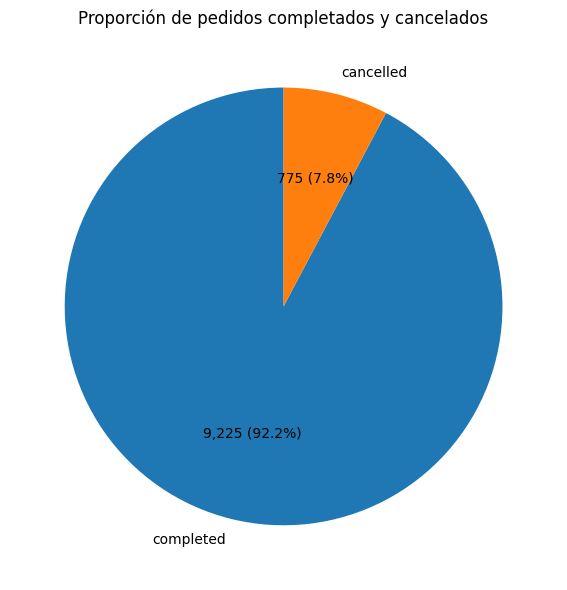

In [ ]:
"""
Tipo de gráfico: gráfico de torta.
Por qué lo elegimos: permite mostrar proporciones sobre un total. Al haber solo dos estados(cancelado y completado) se puede ver rapidamente que porcentaje representa cada uno.
"""
status_counts = df["order_status"].value_counts()
total = status_counts.values.sum()

plt.figure(figsize=(6, 6))
plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct=lambda pct: f"{int(round(pct * total / 100)):,} ({pct:.1f}%)",
    startangle=90
)

plt.title("Proporción de pedidos completados y cancelados")
plt.tight_layout()
plt.show()

## Categorías que inciden en la cancelación en relación al promedio

### Ciudad

La ciudad en la que se realizan los pedidos pareciera tener una incidencia, mostrando que Phoenix (9,2%) y Chicago (9,6%) tienden a cancelar por encima de nuestra referencia (7,8%).

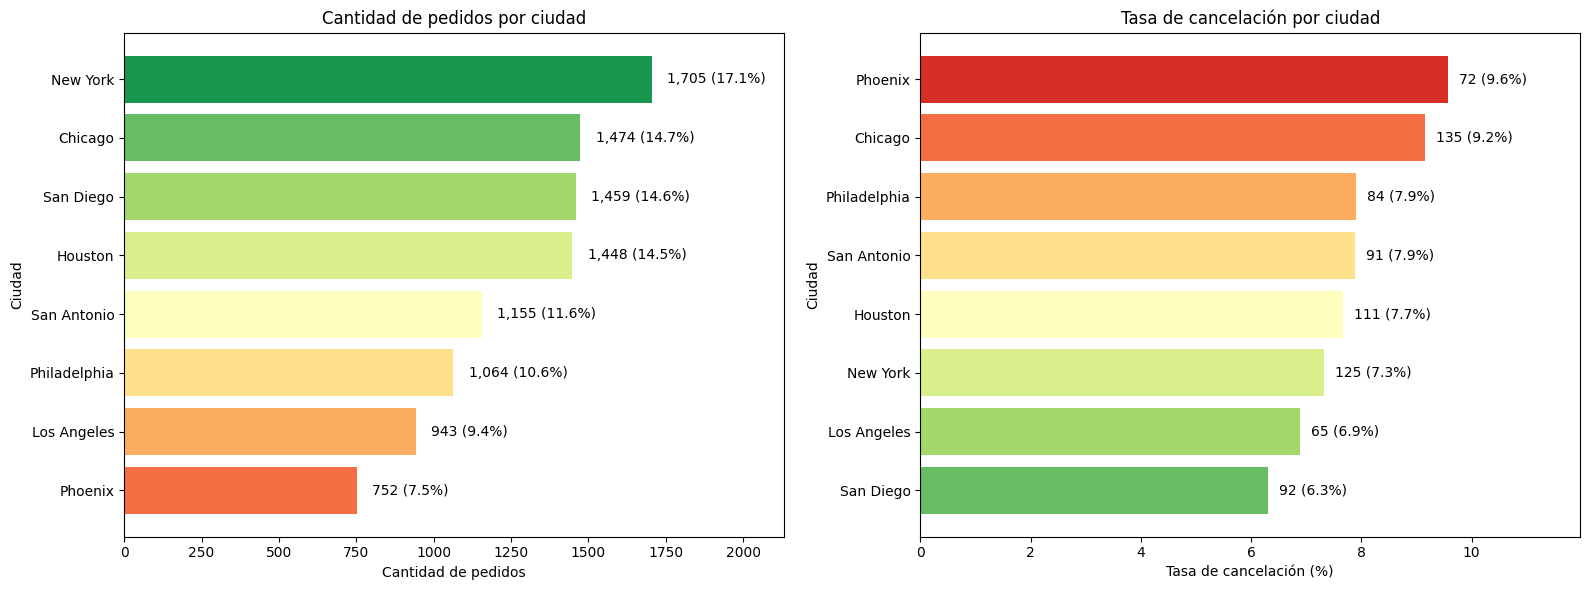

In [ ]:
"""
Tipo de gráfico: barras horizontales.
Por qué lo elegimos: permite comparar porcentajes, o valores, entre varias ciudades. Facilitan la lectura cuando hay varias categorías.
"""

city_counts = (
    df["restaurant_city"]
    .value_counts()
    .sort_values(ascending=True)
)

cancelacion_ciudad = (
    df.groupby("restaurant_city")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=True)
)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

plt.subplots_adjust(wspace=0.4)

colors1 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(city_counts))
)

bars1 = ax1.barh(
    city_counts.index,
    city_counts.values,
    color=colors1
)

total_pedidos = city_counts.sum()

for bar in bars1:
    width = bar.get_width()
    pct = width / total_pedidos * 100

    ax1.text(
        width + total_pedidos * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} ({pct:.1f}%)",
        va="center"
    )

ax1.set_xlim(0, city_counts.max() * 1.25)
ax1.set_xlabel("Cantidad de pedidos")
ax1.set_ylabel("Ciudad")
ax1.set_title("Cantidad de pedidos por ciudad")


colors2 = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.9, len(cancelacion_ciudad))
)

bars2 = ax2.barh(
    cancelacion_ciudad.index,
    cancelacion_ciudad["tasa_cancelacion"],
    color=colors2
)

for bar, (_, row) in zip(bars2, cancelacion_ciudad.iterrows()):
    tasa = row["tasa_cancelacion"]
    cancelados = int(row["cancelados"])

    ax2.text(
        tasa + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{cancelados} ({tasa:.1f}%)",
        va="center"
    )

ax2.set_xlim(0, cancelacion_ciudad["tasa_cancelacion"].max() * 1.25)
ax2.set_xlabel("Tasa de cancelación (%)")
ax2.set_ylabel("Ciudad")
ax2.set_title("Tasa de cancelación por ciudad")

plt.tight_layout()
plt.show()

### Delay en la entrega

Analizando `delivery_duration_actual` - `delivery_duration_estimated` construimos la categoría `delay`. Esta solo funciona para pedidos completados, ya que no podemos considerar un `delivery_duration_actual` de un pedido que no se completó. Esto nos arroja una correlación directa con las dos ciudades de mayor cancelación. Vemos que estas dos son las que menor promedio de delay tienen, indicando que tal vez la exigencia de puntualidad sea mayor allí.
Una recomendación podría ser ampliar la estimación, o bien considerar estrategias de selección de logística más enfocada en acortar los plazos de entrega.

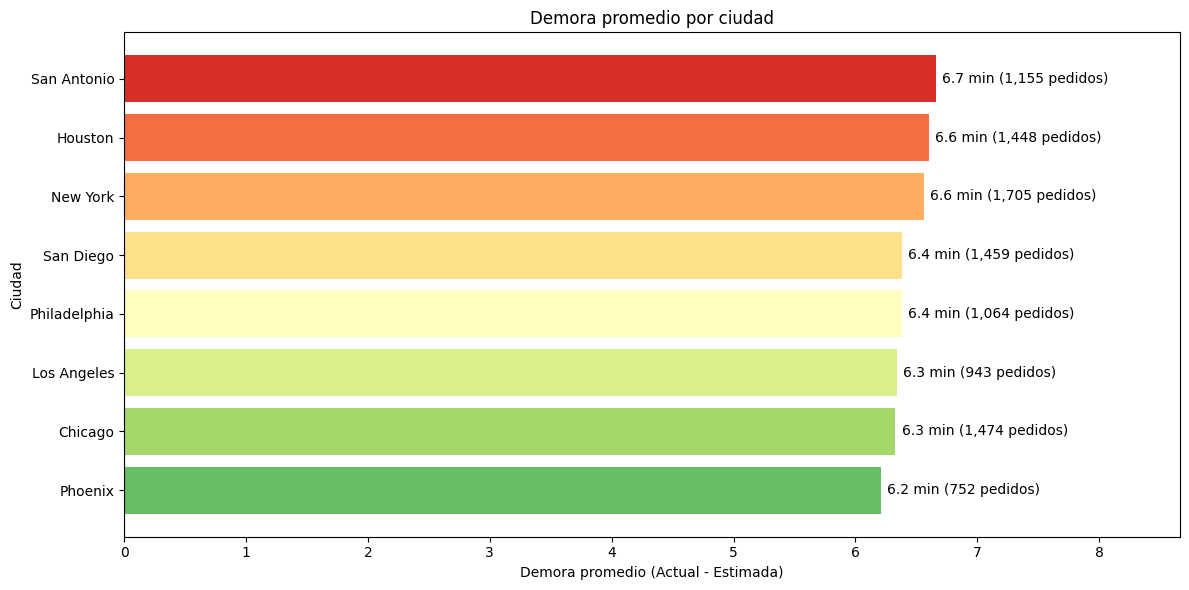

In [ ]:
df_delay = df.copy()

df_delay["delay"] = (
    df_delay["delivery_duration_actual"]
    - df_delay["delivery_duration_estimated"]
)


city_delay = (
    df_delay
    .groupby("restaurant_city")
    .agg(
        pedidos=("order_id", "count"),
        demora_promedio=("delay", "mean")
    )
    .sort_values("demora_promedio")
)


plt.figure(figsize=(12, 6))

colors = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.9, len(city_delay))
)

bars = plt.barh(
    city_delay.index,
    city_delay["demora_promedio"],
    color=colors
)

for bar, (_, row) in zip(
    bars,
    city_delay.iterrows()
):
    delay = row["demora_promedio"]
    pedidos = int(row["pedidos"])

    plt.text(
        delay + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{delay:.1f} min ({pedidos:,} pedidos)",
        va="center",
        ha="left"
    )


plt.axvline(
    0,
    color="black",
    linestyle="--",
    alpha=0.7
)


plt.xlim(0, city_delay["demora_promedio"].max() + 2)

plt.xlabel(
    "Demora promedio (Actual - Estimada)"
)

plt.ylabel("Ciudad")

plt.title(
    "Demora promedio por ciudad"
)

plt.tight_layout()
plt.show()

### Precipitaciones

Al analizar la distribución de completados vs cancelados, notamos que los días de lluvia la cancelación baja en relación al promedio en un 1%. Esto indicaría una mayor propensión a la espera de parte de los clientes, o bien una mayor empatía ante casos de logística operando en condiciones adversas.

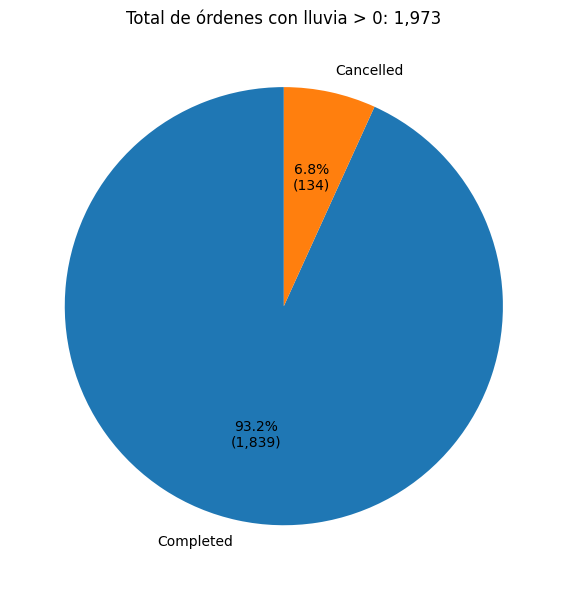

In [ ]:
df_rain = df[
    (df["weather_precipitation"] > 0)
    & (df["order_status"].isin(["completed", "cancelled"]))
]

status_counts = (
    df_rain["order_status"]
    .value_counts()
    .reindex(["completed", "cancelled"])
    .fillna(0)
)

total = status_counts.sum()

def autopct_with_count(pct):
    count = int(round(pct * total / 100))
    return f"{pct:.1f}%\n({count:,})"


plt.figure(figsize=(6, 6))

plt.pie(
    status_counts,
    labels=["Completed", "Cancelled"],
    autopct=autopct_with_count,
    startangle=90
)

plt.title(
    f"Total de órdenes con lluvia > 0: {total:,}"
)

plt.tight_layout()
plt.show()

### Categorías de comidas

Vemos que según qué categoría de comida incluye el pedido hay una diferente tasa de cancelación, mostrando mayores índices sobre la media la comida rápida Hamburguesas (8.6%) y Bebidas (8.4%) pero que ante platos más elaborados la cancelación baja, por ejemplo Menú ejecutivo, si se nos permite la traducción en base a "Main Course" (6.2%) y Postre (6.7%).
Esto también nos sugiere que clientes que solicitan platos más complejos presentan una mayor tolerancia antes de cancelar.

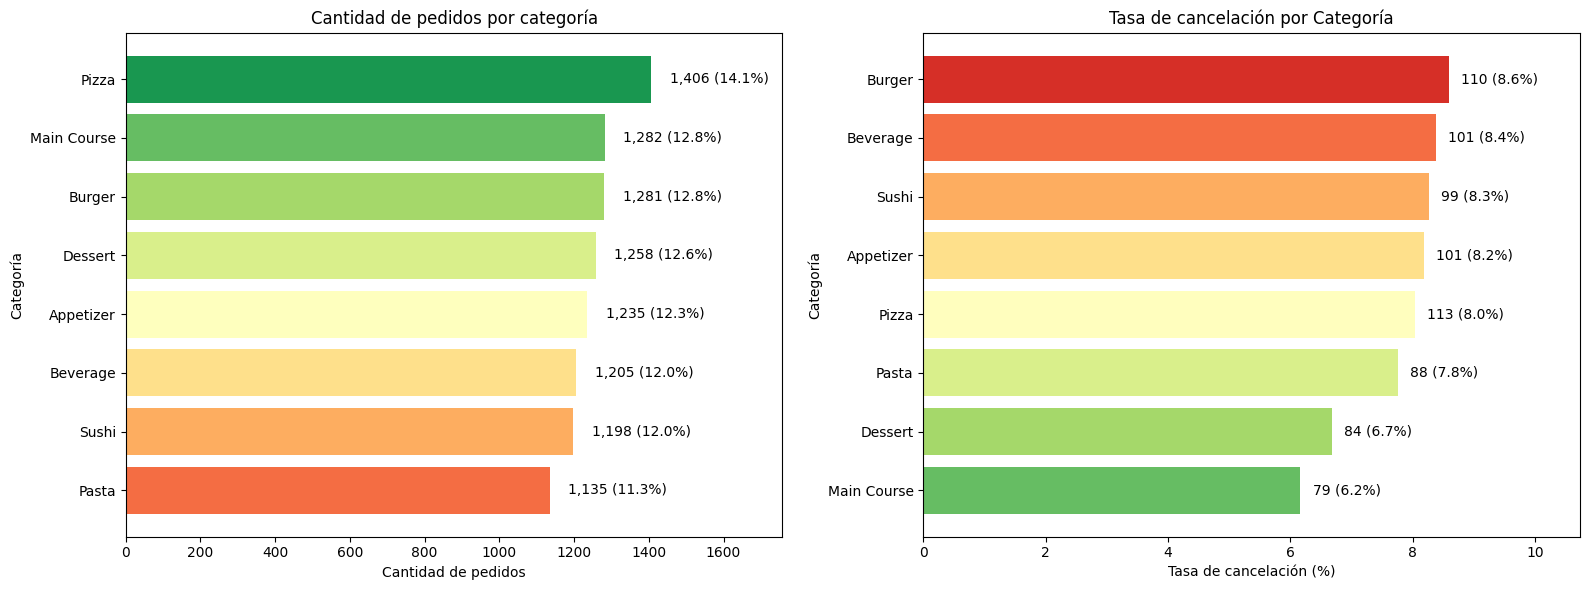

In [ ]:
"""
Tipo de gráfico: barras horizontales.
Por qué lo elegimos: permite comparar porcentajes, o valores, entre varias ciudades. Facilitan la lectura cuando hay varias categorías.
"""

item_counts = (
    df["menu_item_category"]
    .value_counts()
    .sort_values(ascending=True)
)

cancelacion_item = (
    df.groupby("menu_item_category")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=True)
)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

plt.subplots_adjust(wspace=0.4)

colors1 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(item_counts))
)

bars1 = ax1.barh(
    item_counts.index,
    item_counts.values,
    color=colors1
)

total_pedidos = item_counts.sum()

for bar in bars1:
    width = bar.get_width()
    pct = width / total_pedidos * 100

    ax1.text(
        width + total_pedidos * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} ({pct:.1f}%)",
        va="center"
    )

ax1.set_xlim(0, item_counts.max() * 1.25)
ax1.set_xlabel("Cantidad de pedidos")
ax1.set_ylabel("Categoría")
ax1.set_title("Cantidad de pedidos por categoría")

colors2 = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.9, len(cancelacion_item))
)

bars2 = ax2.barh(
    cancelacion_item.index,
    cancelacion_item["tasa_cancelacion"],
    color=colors2
)

for bar, (_, row) in zip(bars2, cancelacion_item.iterrows()):
    tasa = row["tasa_cancelacion"]
    cancelados = int(row["cancelados"])

    ax2.text(
        tasa + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{cancelados} ({tasa:.1f}%)",
        va="center"
    )

ax2.set_xlim(0, cancelacion_item["tasa_cancelacion"].max() * 1.25)
ax2.set_xlabel("Tasa de cancelación (%)")
ax2.set_ylabel("Categoría")
ax2.set_title("Tasa de cancelación por Categoría")

plt.tight_layout()
plt.show()

### Canales de adquisición de clientes

Una sorpresa de este análisis es que dos canales muestran mayores tasas de canelación, `referral` (8,9%) y `paid_ads` (8,1%). Quizás podríamos pensar que los referrals solo están usando el código, aprovechando cierto beneficio, y cancelando, y que los paid ads no están apuntando al público idóneo para nuestros restaurants.

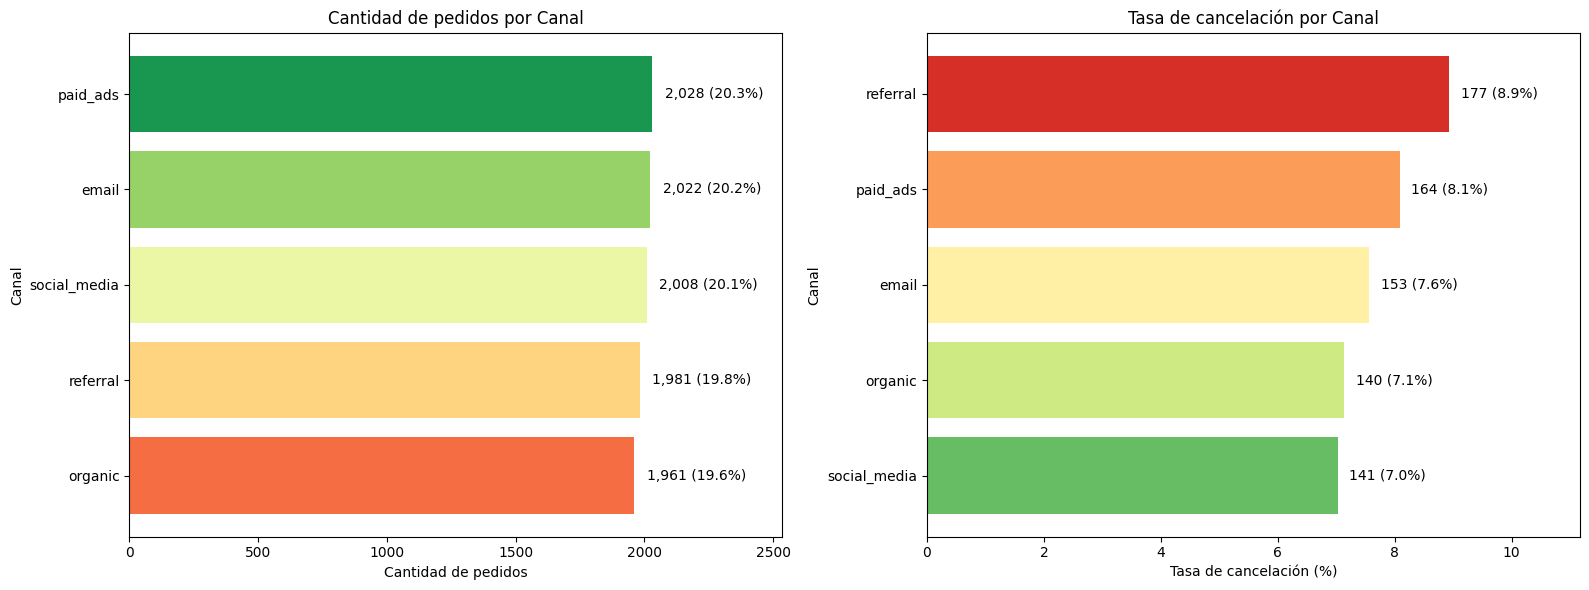

In [ ]:
"""
Tipo de gráfico: barras horizontales.
Por qué lo elegimos: permite comparar porcentajes, o valores, entre varias ciudades. Facilitan la lectura cuando hay varias categorías.
"""


channel = (
    df["customer_acquisition_channel"]
    .value_counts()
    .sort_values(ascending=True)
)



cancelacion_item = (
    df.groupby("customer_acquisition_channel")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=True)
)



fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

plt.subplots_adjust(wspace=0.4)



colors1 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(channel))
)

bars1 = ax1.barh(
    channel.index,
    channel.values,
    color=colors1
)

total_pedidos = channel.sum()

for bar in bars1:
    width = bar.get_width()
    pct = width / total_pedidos * 100

    ax1.text(
        width + total_pedidos * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} ({pct:.1f}%)",
        va="center"
    )

ax1.set_xlim(0, channel.max() * 1.25)
ax1.set_xlabel("Cantidad de pedidos")
ax1.set_ylabel("Canal")
ax1.set_title("Cantidad de pedidos por Canal")



colors2 = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.9, len(cancelacion_item))
)

bars2 = ax2.barh(
    cancelacion_item.index,
    cancelacion_item["tasa_cancelacion"],
    color=colors2
)

for bar, (_, row) in zip(bars2, cancelacion_item.iterrows()):
    tasa = row["tasa_cancelacion"]
    cancelados = int(row["cancelados"])

    ax2.text(
        tasa + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{cancelados} ({tasa:.1f}%)",
        va="center"
    )

ax2.set_xlim(0, cancelacion_item["tasa_cancelacion"].max() * 1.25)
ax2.set_xlabel("Tasa de cancelación (%)")
ax2.set_ylabel("Canal")
ax2.set_title("Tasa de cancelación por Canal")

plt.tight_layout()
plt.show()

### Tipos de comida

Algunas cocinas del mundo presentan mayor tasa, pero nos resultó muy difícil explicar este fenómeno. Podría ser tarea para futuras exploraciones, y, de momento, solo considerarlo como un hecho a tener en cuenta por los locales: si se van a especializar en comida India o Mediterránea, estas cancelan por arriba de la media.,

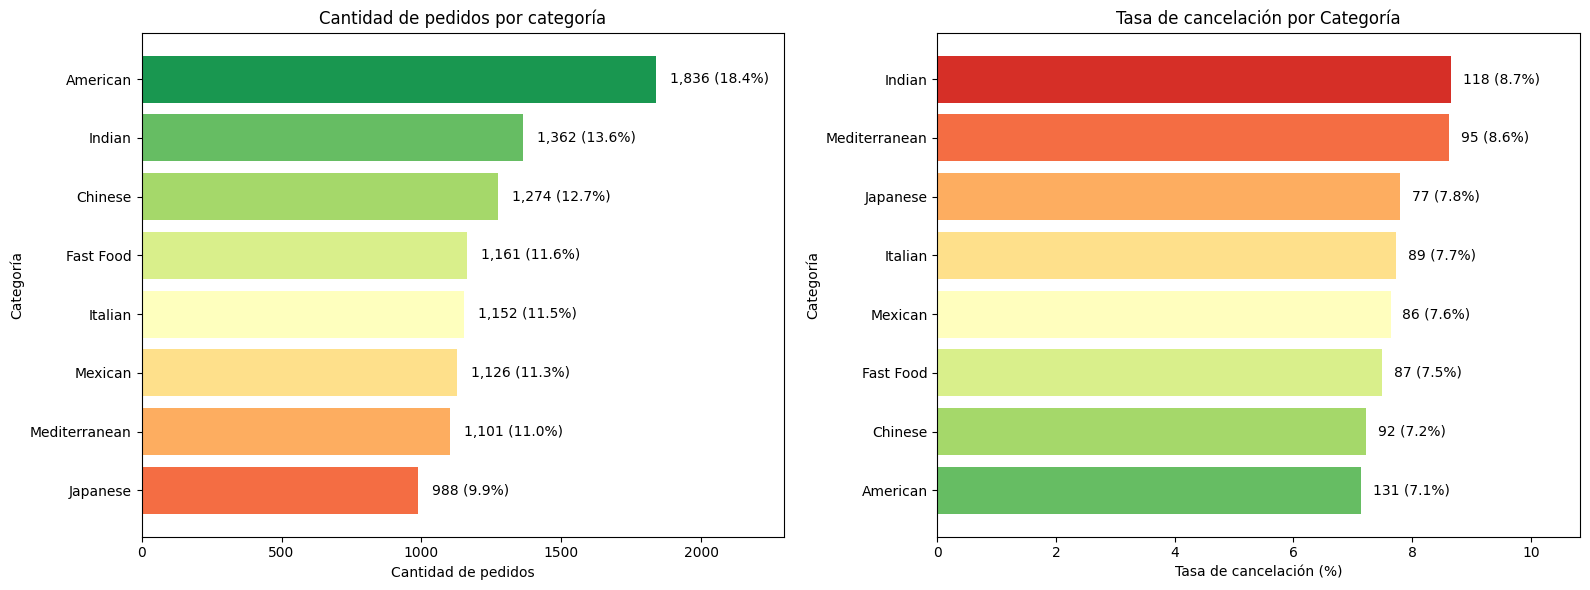

In [ ]:
"""
Tipo de gráfico: barras horizontales.
Por qué lo elegimos: permite comparar porcentajes, o valores, entre varias ciudades. Facilitan la lectura cuando hay varias categorías.
"""

cuisine = (
    df["restaurant_cuisine"]
    .value_counts()
    .sort_values(ascending=True)
)


cancelacion_item = (
    df.groupby("restaurant_cuisine")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=True)
)


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

plt.subplots_adjust(wspace=0.4)


colors1 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(cuisine))
)

bars1 = ax1.barh(
    cuisine.index,
    cuisine.values,
    color=colors1
)

total_pedidos = cuisine.sum()

for bar in bars1:
    width = bar.get_width()
    pct = width / total_pedidos * 100

    ax1.text(
        width + total_pedidos * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} ({pct:.1f}%)",
        va="center"
    )

ax1.set_xlim(0, cuisine.max() * 1.25)
ax1.set_xlabel("Cantidad de pedidos")
ax1.set_ylabel("Categoría")
ax1.set_title("Cantidad de pedidos por categoría")

colors2 = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.9, len(cancelacion_item))
)

bars2 = ax2.barh(
    cancelacion_item.index,
    cancelacion_item["tasa_cancelacion"],
    color=colors2
)

for bar, (_, row) in zip(bars2, cancelacion_item.iterrows()):
    tasa = row["tasa_cancelacion"]
    cancelados = int(row["cancelados"])

    ax2.text(
        tasa + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{cancelados} ({tasa:.1f}%)",
        va="center"
    )

ax2.set_xlim(0, cancelacion_item["tasa_cancelacion"].max() * 1.25)
ax2.set_xlabel("Tasa de cancelación (%)")
ax2.set_ylabel("Categoría")
ax2.set_title("Tasa de cancelación por Categoría")

plt.tight_layout()
plt.show()

## Categorías que no inciden en la cancelación en relación al promedio

### Loyalty Tier

La creación de distintos Tiers de cliente no resulta relevante a la hora de prevenir cancelaciones, mostrando una distribución altamente homogénea y carente de valor explicativo.

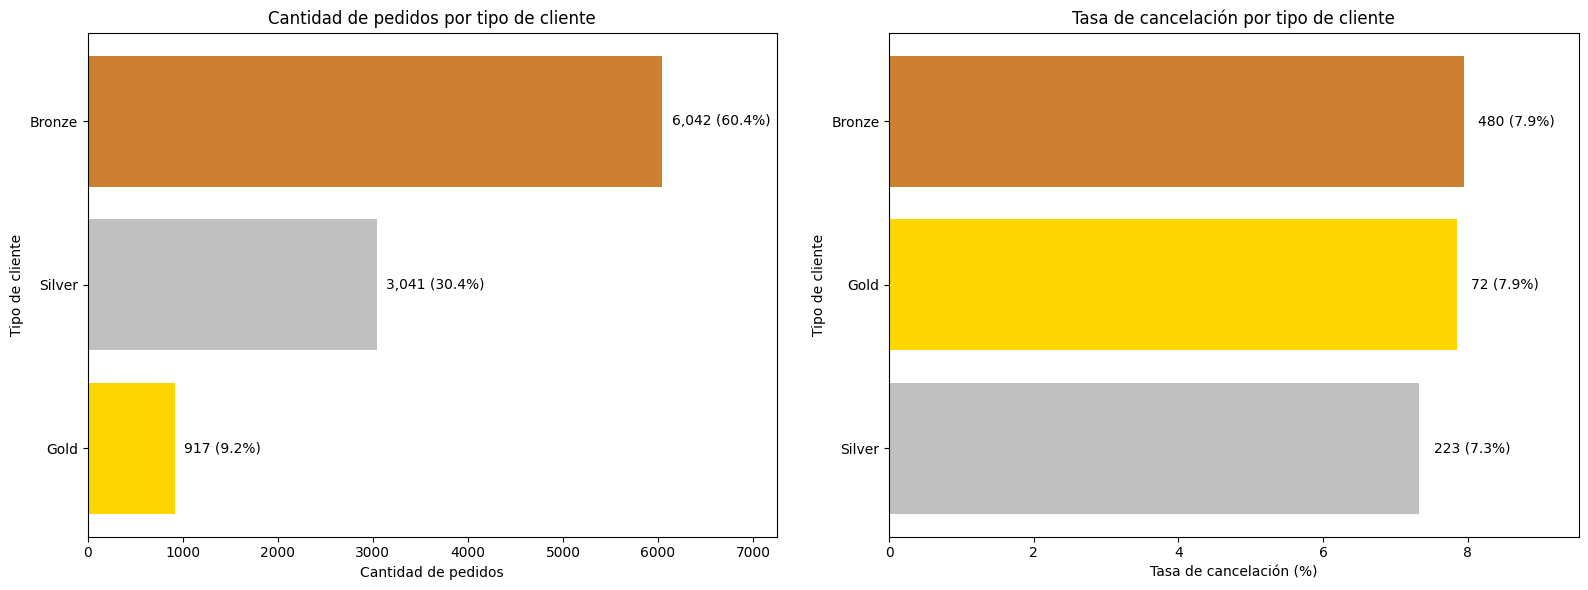

In [ ]:
loyalty_counts = (
    df["customer_loyalty_tier"]
    .value_counts()
    .sort_values(ascending=True)
)

cancelacion_loyalty = (
    df.groupby("customer_loyalty_tier")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=True)
)

color_map = {
    "Bronze": "#cd7f32",
    "Silver": "#c0c0c0",
    "Gold": "#ffd700"
}

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

plt.subplots_adjust(wspace=0.4)

colors1 = loyalty_counts.index.map(color_map)

bars1 = ax1.barh(
    loyalty_counts.index,
    loyalty_counts.values,
    color=colors1
)

total_pedidos = loyalty_counts.sum()

for bar in bars1:
    width = bar.get_width()
    pct = width / total_pedidos * 100

    ax1.text(
        width + total_pedidos * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} ({pct:.1f}%)",
        va="center"
    )

ax1.set_xlim(0, loyalty_counts.max() * 1.2)
ax1.set_xlabel("Cantidad de pedidos")
ax1.set_ylabel("Tipo de cliente")
ax1.set_title("Cantidad de pedidos por tipo de cliente")

colors2 = cancelacion_loyalty.index.map(color_map)

bars2 = ax2.barh(
    cancelacion_loyalty.index,
    cancelacion_loyalty["tasa_cancelacion"],
    color=colors2
)

for bar, (_, row) in zip(bars2, cancelacion_loyalty.iterrows()):
    tasa = row["tasa_cancelacion"]
    cancelados = int(row["cancelados"])

    ax2.text(
        tasa + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{cancelados} ({tasa:.1f}%)",
        va="center"
    )

ax2.set_xlim(0, cancelacion_loyalty["tasa_cancelacion"].max() * 1.2)
ax2.set_xlabel("Tasa de cancelación (%)")
ax2.set_ylabel("Tipo de cliente")
ax2.set_title("Tasa de cancelación por tipo de cliente")

plt.tight_layout()
plt.show()

El tier no parece explicar mucho, ya que los 3 presentan una distribución homogénea y similar al porcentaje total de cancelación. Buscaremos factores geográficos.

Acá sí notamos ciertos desvíos, siendo Phoenix y Chicago quienes presentan un porcentaje de cancelación por encima de la media. Phoenix, incluso, en base a un volumen muy inferior de trabajo, señalando una ciudad operativamente poco atractiva.
Chicago sería una ciudad muy interesante de profundizar, ya que es la segunda mayor en volumen y segunda también con mayor porcentaje de cancelaciones.
San Diego podría postularse como nuestra ciudad modelo, ya que tiene una diferencia mínima en volumen con Chicago, posicionándose en el podio, pero es la que presenta menor porcentaje de cancelaciones de todas las analizadas.

### Temperatura

En la temperatura hicimos un poco de énfasis también, pero no notamos que esta incida, mostrando promedios muy similares en casos de cancelación o entrega efectiva, y sin mayores sobresaltos incluso aplicando distribuciones en rangos de temperatura.

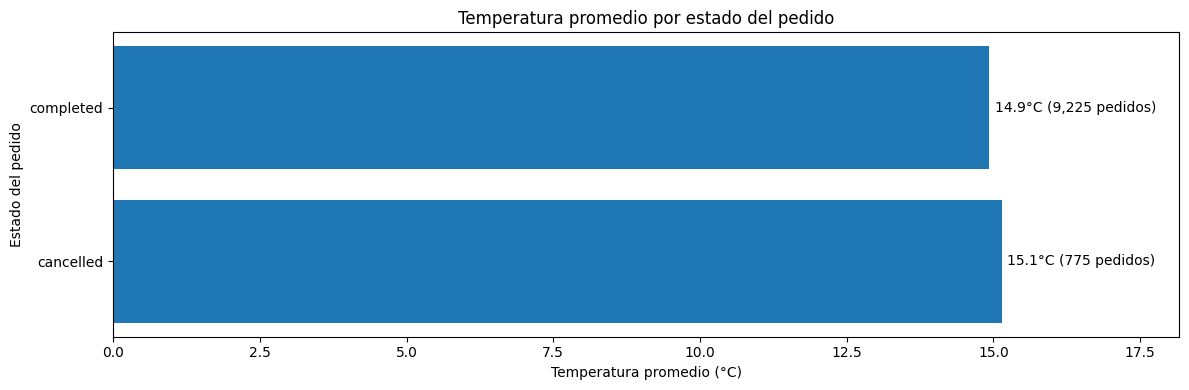

In [ ]:
status_stats = (
    df.groupby("order_status")
    .agg(
        pedidos=("order_id", "count"),
        temperatura_promedio=("weather_temperature", "mean")
    )
    .sort_values("order_status", ascending=True)
)

plt.figure(figsize=(12, 4))

bars = plt.barh(
    status_stats.index,
    status_stats["temperatura_promedio"]
)


for bar, (_, row) in zip(bars, status_stats.iterrows()):

    temp = row["temperatura_promedio"]
    pedidos = int(row["pedidos"])

    plt.text(
        temp + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{temp:.1f}°C ({pedidos:,} pedidos)",
        va="center"
    )

plt.xlim(
    0,
    status_stats["temperatura_promedio"].max() * 1.2
)

plt.xlabel("Temperatura promedio (°C)")
plt.ylabel("Estado del pedido")
plt.title("Temperatura promedio por estado del pedido")

plt.tight_layout()
plt.show()

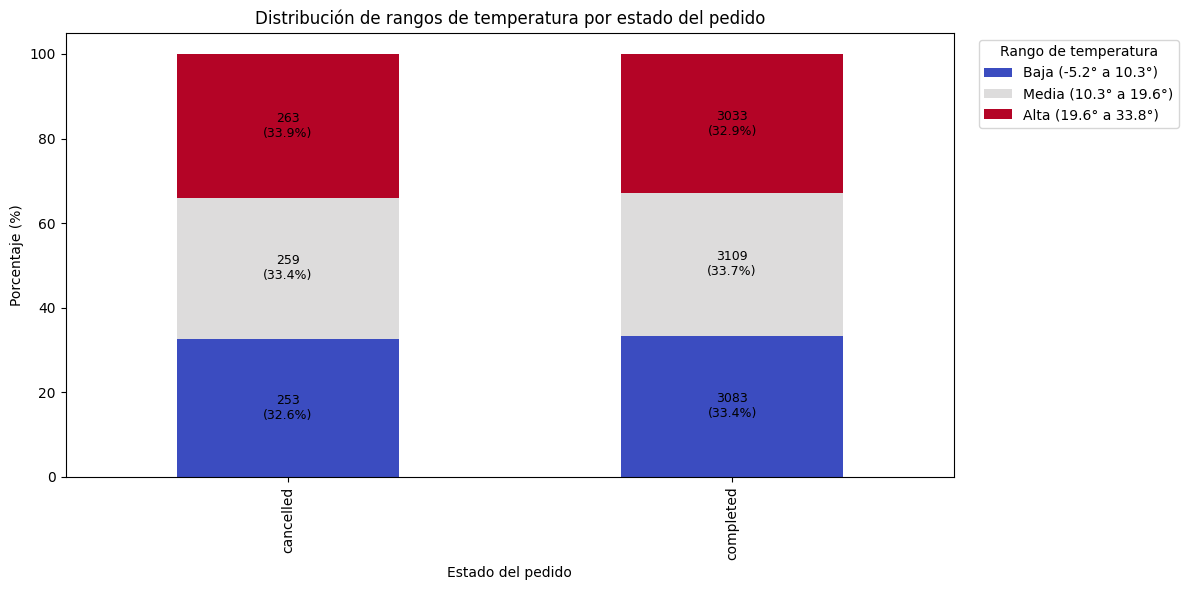

In [ ]:
df_temp = df.copy()

df_temp["temp_categoria"], bins = pd.qcut(
    df_temp["weather_temperature"],
    q=3,
    labels=["Baja", "Media", "Alta"],
    retbins=True
)


temp_labels = {
    "Baja":  f"Baja ({bins[0]:.1f}° a {bins[1]:.1f}°)",
    "Media": f"Media ({bins[1]:.1f}° a {bins[2]:.1f}°)",
    "Alta":  f"Alta ({bins[2]:.1f}° a {bins[3]:.1f}°)"
}


temp_status = pd.crosstab(
    df_temp["order_status"],
    df_temp["temp_categoria"]
)


temp_status_pct = (
    temp_status
    .div(temp_status.sum(axis=1), axis=0)
    * 100
)

temp_status_pct.columns = [
    temp_labels[col]
    for col in temp_status_pct.columns
]

temp_status.columns = [
    temp_labels[col]
    for col in temp_status.columns
]

ax = temp_status_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="coolwarm"
)

for container_idx, container in enumerate(ax.containers):

    counts = temp_status.iloc[:, container_idx].values

    labels = []

    for count, pct in zip(counts, container.datavalues):

        if pct < 5:
            labels.append("")
        else:
            labels.append(
                f"{count}\n({pct:.1f}%)"
            )

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )


plt.title(
    "Distribución de rangos de temperatura por estado del pedido"
)

plt.xlabel("Estado del pedido")
plt.ylabel("Porcentaje (%)")

plt.legend(
    title="Rango de temperatura",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Descuentos

Los tipos de descuento tampoco nos resultaron relevantes para el análisis ya que presentan distribución homogénea.

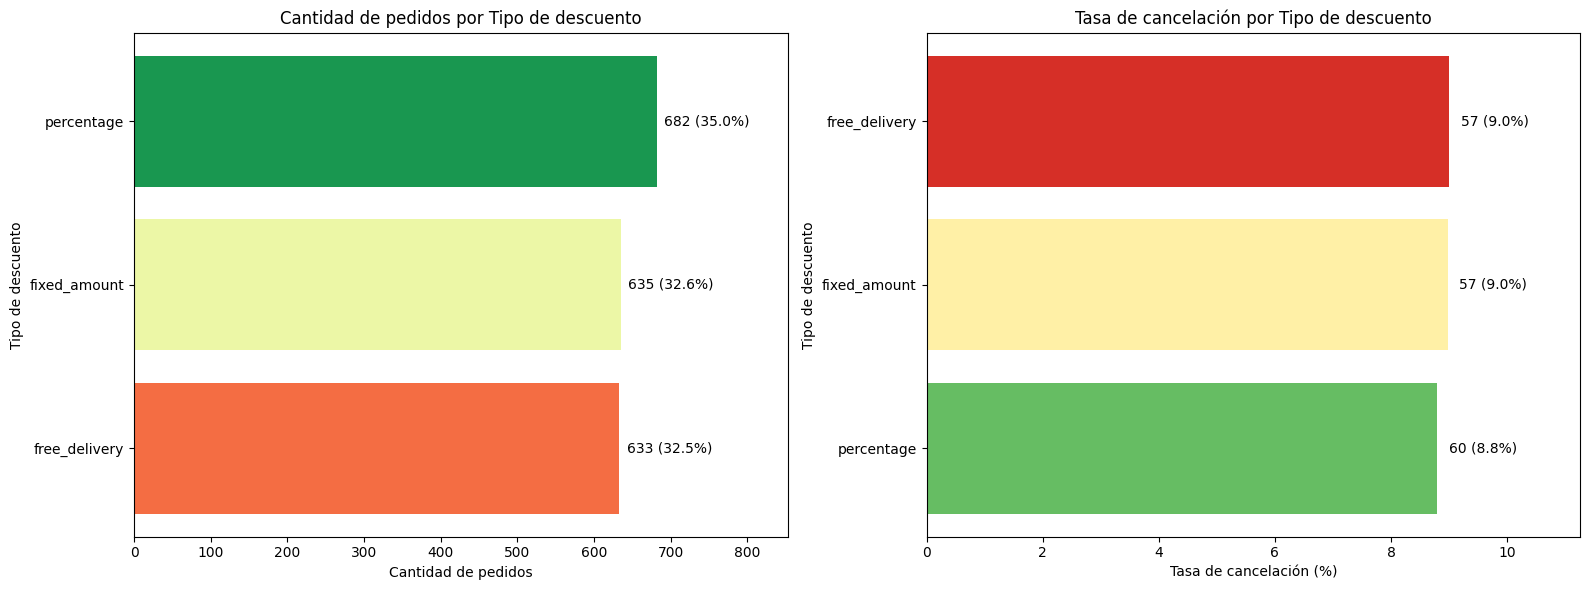

In [ ]:
"""
Tipo de gráfico: barras horizontales.
Por qué lo elegimos: permite comparar porcentajes, o valores, entre varias ciudades. Facilitan la lectura cuando hay varias categorías.
"""


discount = (
    df["discount_type"]
    .value_counts()
    .sort_values(ascending=True)
)


cancelacion_item = (
    df.groupby("discount_type")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=True)
)


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

plt.subplots_adjust(wspace=0.4)


colors1 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(discount))
)

bars1 = ax1.barh(
    discount.index,
    discount.values,
    color=colors1
)

total_pedidos = discount.sum()

for bar in bars1:
    width = bar.get_width()
    pct = width / total_pedidos * 100

    ax1.text(
        width + total_pedidos * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} ({pct:.1f}%)",
        va="center"
    )

ax1.set_xlim(0, discount.max() * 1.25)
ax1.set_xlabel("Cantidad de pedidos")
ax1.set_ylabel("Tipo de descuento")
ax1.set_title("Cantidad de pedidos por Tipo de descuento")


colors2 = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.9, len(cancelacion_item))
)

bars2 = ax2.barh(
    cancelacion_item.index,
    cancelacion_item["tasa_cancelacion"],
    color=colors2
)

for bar, (_, row) in zip(bars2, cancelacion_item.iterrows()):
    tasa = row["tasa_cancelacion"]
    cancelados = int(row["cancelados"])

    ax2.text(
        tasa + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{cancelados} ({tasa:.1f}%)",
        va="center"
    )

ax2.set_xlim(0, cancelacion_item["tasa_cancelacion"].max() * 1.25)
ax2.set_xlabel("Tasa de cancelación (%)")
ax2.set_ylabel("Tipo de descuento")
ax2.set_title("Tasa de cancelación por Tipo de descuento")

plt.tight_layout()
plt.show()

### Días de la semana y días especiales

Tampoco resultó relevante para el análisis la categorización entre días de la semana vs fines de semana, o bien feriados y días normales. La cancelación se mantuvo estable a lo largo de todos.

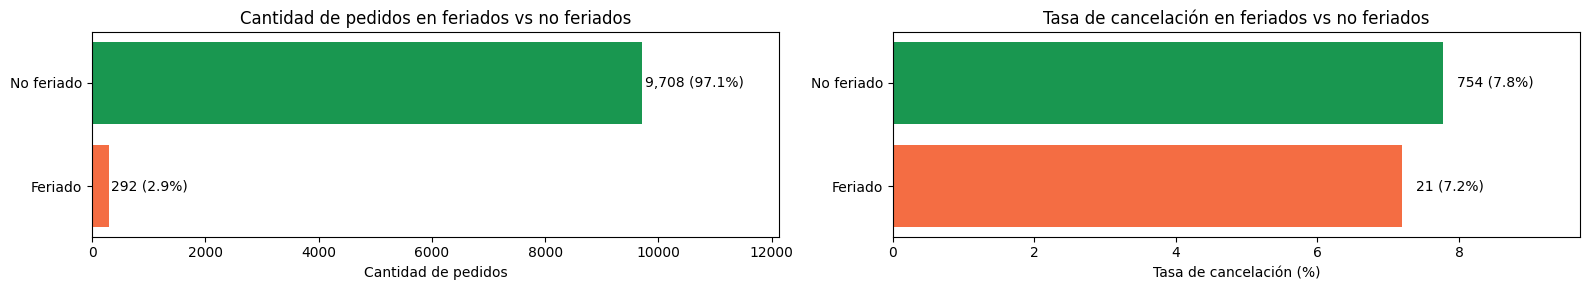

In [ ]:
holiday_labels = {True: "Feriado", False: "No feriado"}

holiday = (
    df["is_holiday"]
    .map(holiday_labels)
    .value_counts()
    .sort_values(ascending=True)
)


cancelacion_item = (
    df.assign(is_holiday=df["is_holiday"].map(holiday_labels))
    .groupby("is_holiday")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
)

shared_index = holiday.index.tolist()
cancelacion_item = cancelacion_item.reindex(shared_index)


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 3)
)

plt.subplots_adjust(wspace=0.4)

colors1 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(holiday))
)

bars1 = ax1.barh(
    holiday.index,
    holiday.values,
    color=colors1
)

total_pedidos = holiday.sum()

for bar in bars1:
    width = bar.get_width()
    pct = width / total_pedidos * 100

    ax1.text(
        width + total_pedidos * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} ({pct:.1f}%)",
        va="center"
    )

ax1.set_xlim(0, holiday.max() * 1.25)
ax1.set_xlabel("Cantidad de pedidos")
ax1.set_title("Cantidad de pedidos en feriados vs no feriados")

colors2 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(cancelacion_item))
)

bars2 = ax2.barh(
    cancelacion_item.index,
    cancelacion_item["tasa_cancelacion"],
    color=colors2
)

for bar, (_, row) in zip(bars2, cancelacion_item.iterrows()):
    tasa = row["tasa_cancelacion"]
    cancelados = int(row["cancelados"])

    ax2.text(
        tasa + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{cancelados} ({tasa:.1f}%)",
        va="center"
    )

ax2.set_xlim(0, cancelacion_item["tasa_cancelacion"].max() * 1.25)
ax2.set_xlabel("Tasa de cancelación (%)")
ax2.set_title("Tasa de cancelación en feriados vs no feriados")

plt.tight_layout()
plt.show()

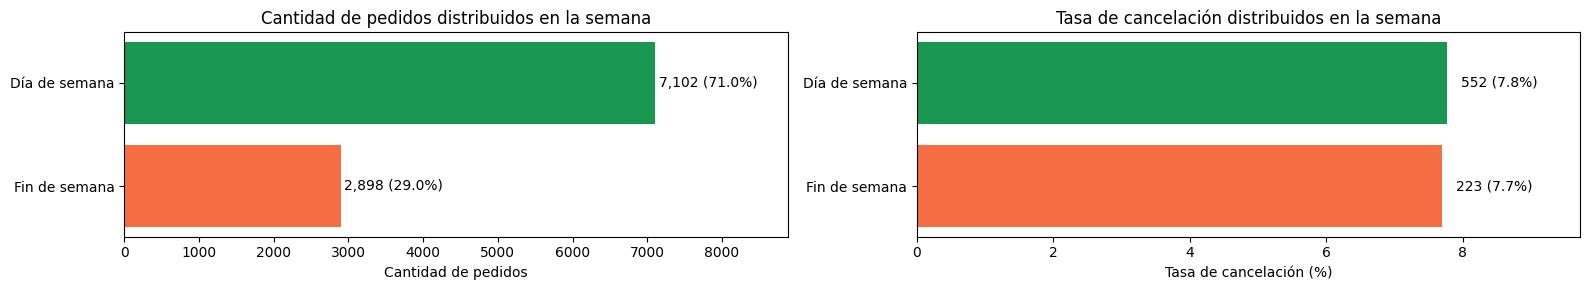

In [ ]:
finde_labels = {True: "Fin de semana", False: "Día de semana"}

finde = (
    df["is_weekend"]
    .map(finde_labels)
    .value_counts()
    .sort_values(ascending=True)
)


cancelacion_item = (
    df.assign(is_weekend=df["is_weekend"].map(finde_labels))
    .groupby("is_weekend")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
)

shared_index = finde.index.tolist()
cancelacion_item = cancelacion_item.reindex(shared_index)



fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 3)
)

plt.subplots_adjust(wspace=0.4)


colors1 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(finde))
)

bars1 = ax1.barh(
    finde.index,
    finde.values,
    color=colors1
)

total_pedidos = finde.sum()

for bar in bars1:
    width = bar.get_width()
    pct = width / total_pedidos * 100

    ax1.text(
        width + total_pedidos * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} ({pct:.1f}%)",
        va="center"
    )

ax1.set_xlim(0, finde.max() * 1.25)
ax1.set_xlabel("Cantidad de pedidos")
ax1.set_title("Cantidad de pedidos distribuidos en la semana")



colors2 = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(cancelacion_item))
)

bars2 = ax2.barh(
    cancelacion_item.index,
    cancelacion_item["tasa_cancelacion"],
    color=colors2
)

for bar, (_, row) in zip(bars2, cancelacion_item.iterrows()):
    tasa = row["tasa_cancelacion"]
    cancelados = int(row["cancelados"])

    ax2.text(
        tasa + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{cancelados} ({tasa:.1f}%)",
        va="center"
    )

ax2.set_xlim(0, cancelacion_item["tasa_cancelacion"].max() * 1.25)
ax2.set_xlabel("Tasa de cancelación (%)")
ax2.set_title("Tasa de cancelación distribuidos en la semana")

plt.tight_layout()
plt.show()

# MODELO PREDICTIVO PARA CANCELACIONES

¿Por qué es una buena elección acá?
La idea central es que el modelo aprende, a partir del historial de pedidos pasados, qué combinación de características (ciudad, tipo de cocina, canal de adquisición, clima, etc.) se asocia con una mayor probabilidad de cancelación. Una vez entrenado, para cada pedido nuevo devuelve un número entre 0 y 1 — por ejemplo, 0.73 — que se interpreta directamente como "este pedido tiene un 73% de probabilidad de cancelarse".

¿Qué la hace especialmente útil acá?
Tres cosas concretas:

Es interpretable. A diferencia de modelos más complejos, la regresión logística te dice exactamente cuánto contribuye cada variable a la predicción. Podés ver, por ejemplo, que los pedidos de hamburguesas tienen un coeficiente positivo, lo que significa que aumentan la probabilidad de cancelación.
Este funciona bien con variables mixtas. Por ejemplo variables numéricas (temperatura, duración estimada) y categóricas (ciudad, tipo de cocina).
Es un buen punto de partida. Antes de ir a modelos más sofisticados como XGBoost, la regresión logística te da una línea base sólida. Si un modelo complejo no la supera por mucho, quizás no vale la pena la complejidad extra.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)


df_model = df.copy()

df_model["cancelled"] = (
    df_model["order_status"] == "cancelled"
).astype(int)


features = [
    "restaurant_city",
    "restaurant_cuisine",
    "menu_item_category",
    "customer_acquisition_channel",
    "discount_type",
    "weather_temperature",
    "weather_precipitation",
    "delivery_duration_estimated",
    "is_weekend",
    "is_holiday"
]

target = "cancelled"

X = df_model[features]
y = df_model[target]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


categorical_features = [
    "restaurant_city",
    "restaurant_cuisine",
    "menu_item_category",
    "customer_acquisition_channel",
    "discount_type"
]

numeric_features = [
    "weather_temperature",
    "weather_precipitation",
    "delivery_duration_estimated",
    "is_weekend",
    "is_holiday"
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        )
    ]
)


logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        )
    )
])

logistic_model.fit(X_train, y_train)


y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]


print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)

print("\nROC AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient":
            logistic_model
            .named_steps["classifier"]
            .coef_[0]
    })
)

print("\nTOP FEATURES INCREASING CANCELLATION")
print(
    coefficients
    .sort_values("coefficient", ascending=False)
    .head(20)
)

print("\nTOP FEATURES REDUCING CANCELLATION")
print(
    coefficients
    .sort_values("coefficient", ascending=True)
    .head(20)
)

LOGISTIC REGRESSION

ROC AUC:
0.512307019844392

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.56      0.70      1845
           1       0.09      0.48      0.14       155

    accuracy                           0.56      2000
   macro avg       0.51      0.52      0.42      2000
weighted avg       0.86      0.56      0.66      2000


Confusion Matrix:
[[1040  805]
 [  80   75]]

TOP FEATURES INCREASING CANCELLATION
                                       feature  coefficient
5                 cat__restaurant_city_Phoenix     0.275627
11              cat__restaurant_cuisine_Indian     0.190566
18              cat__menu_item_category_Burger     0.124819
30            cat__discount_type_free_delivery     0.121613
27  cat__customer_acquisition_channel_referral     0.121280
6             cat__restaurant_city_San Antonio     0.117474
0                 cat__restaurant_city_Chicago     0.116811
16           cat__menu_item_category_

# CONCLUSIONES Y RECOMENDACIONES

A partir del análisis realizado, se observa que la tasa general de cancelación de pedidos es de aproximadamente *7,8%*. Este valor se utilizó como referencia para comparar el comportamiento de distintas variables del dataset.

El análisis por tipo de cliente muestra que los niveles *Bronze, Silver y Gold* presentan tasas de cancelación relativamente similares. Por este motivo, el nivel de lealtad no parece explicar por sí solo una diferencia importante en las cancelaciones.

En cambio, el análisis por ciudad muestra diferencias más relevantes. *Phoenix* y *Chicago* presentan tasas de cancelación superiores al promedio general. En particular, *Chicago* resulta un caso importante para profundizar, ya que combina un volumen alto de pedidos con una tasa elevada de cancelación. Por otro lado, ciudades como *San Diego* muestran una menor tasa de cancelación, por lo que podrían tomarse como referencia comparativa.

También se observa que algunas categorías de pedido presentan mayor tendencia a la cancelación que otras. Esto permite pensar que las cancelaciones no dependen únicamente del cliente, sino también del tipo de pedido, la ciudad y la experiencia de entrega esperada.

Respecto al desempeño operativo, la comparación entre el tiempo estimado y el tiempo real de entrega permite evaluar posibles desvíos en los pedidos completados. Si bien este análisis no explica directamente las cancelaciones, aporta información útil sobre la gestión de expectativas del cliente.

Como recomendación, se propone focalizar las acciones en las ciudades y categorías con mayor tasa de cancelación, especialmente mediante una mejor comunicación ante posibles demoras, seguimiento del pedido e incentivos específicos para reducir el abandono. Al tratarse de un dataset sintético, estas conclusiones deben interpretarse como hipótesis analíticas y no como causalidades definitivas.